# Premium Battery RUL Analytics - XGBoost
Analisis mendalam sisa umur pakai baterai (Remaining Useful Life) menggunakan 14.268 data sensor.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import pickle
import os

# Ensure backend directory exists
os.makedirs('../backend', exist_ok=True)

## 1. Data Acquisition & Cleaning

In [2]:
# 1. Membaca Data Aki Asli
# Data ini diambil dari dataset_final_battery.csv yang telah diproses dari file Excel mentahan
df = pd.read_csv('../backend/dataset_final_battery.csv')
df.head()

,capacity,soh,voltage_drop,min_voltage,rul,voltage,irt,cca
0,4.5266,99.61,-0.0387,12.8915,14228.0,13.09,11.79,129.2
1,4.4728,99.88,-0.2690,12.8529,14227.0,12.96,13.35,122.2
2,4.5326,99.53,-0.1295,12.8927,14226.0,13.07,12.99,118.9
3,4.4756,101.01,0.1001,12.7977,14225.0,13.07,14.17,122.9
4,4.5127,99.55,-0.0187,12.9368,14224.0,13.01,10.10,129.0


In [3]:
# Definisikan fitur input berdasarkan standar industri PT
features = ['voltage', 'irt', 'cca']
targets = ['rul', 'soh']

X = df[features]
y = df[targets]

## 2. Statistical Correlation Analysis

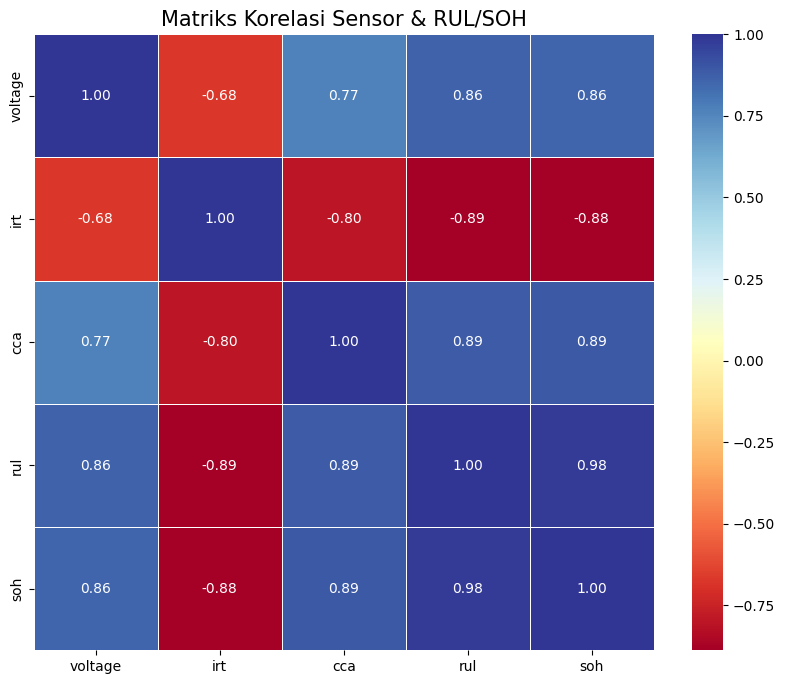

In [4]:
# 9. Analisis Korelasi Antar Sensor (Heatmap)
# Berguna untuk melihat seberapa kuat hubungan antar parameter sensor
plt.figure(figsize=(10, 8))
corr = df[features + targets].corr()
sns.heatmap(corr, annot=True, cmap='RdYlBu', fmt='.2f', linewidths=0.5)
plt.title('Matriks Korelasi Sensor & RUL/SOH', fontsize=15)
plt.show()

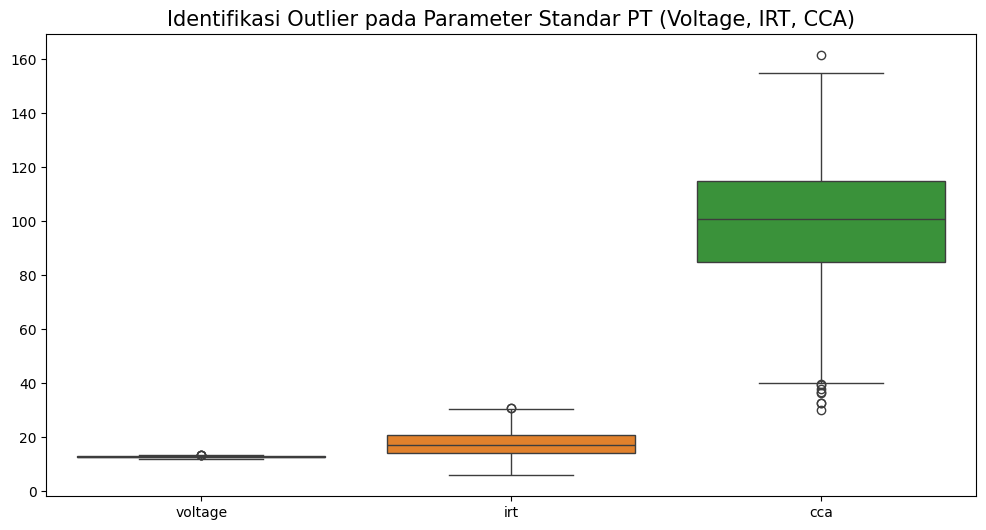

In [5]:
# Visualisasi Outlier dengan Box Plot (Parameter Baru)
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[features])
plt.title('Identifikasi Outlier pada Parameter Standar PT (Voltage, IRT, CCA)', fontsize=15)
plt.show()

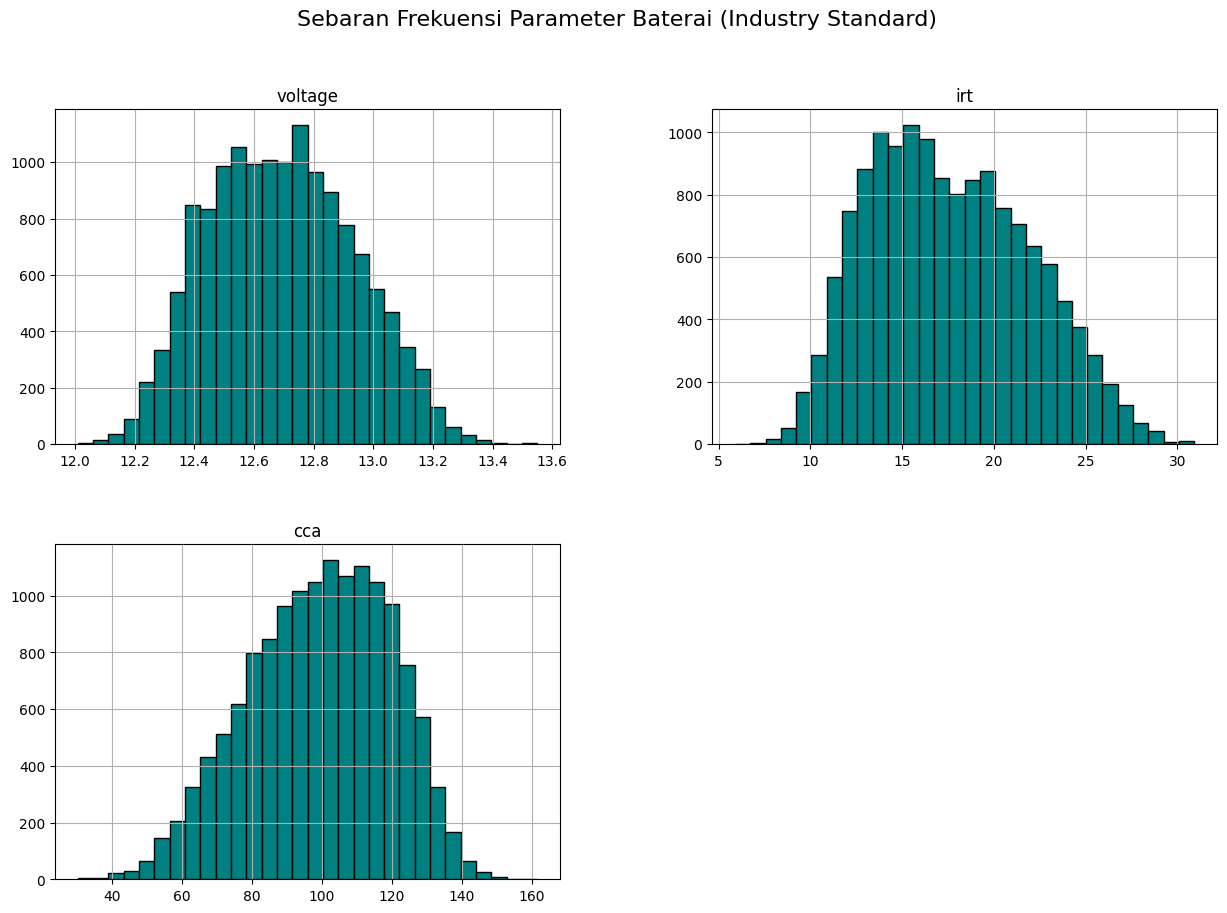

In [6]:
# Distribusi Data (Histogram)
df[features].hist(bins=30, figsize=(15, 10), color='teal', edgecolor='black')
plt.suptitle('Sebaran Frekuensi Parameter Baterai (Industry Standard)', fontsize=16)
plt.show()

In [7]:
# 3. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (11414, 3)
Testing data: (2854, 3)


## 3. XGBoost Model Training

In [8]:
# 4. Train Multi-Output XGBoost Model
from sklearn.multioutput import MultiOutputRegressor
from sklearn.pipeline import Pipeline

# Menggunakan Pipeline dengan Scaler agar hasil lebih stabil
pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    ('regressor', MultiOutputRegressor(xgb.XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        random_state=42
    )))
])

pipeline.fit(X_train, y_train)
print("Multi-Output Model training completed!")

Multi-Output Model training completed!


## 4. Model Evaluation & Visualizations

In [9]:
# 5. Model Evaluation (Full Metrics for Thesis)
y_pred = pipeline.predict(X_test)

# Evaluasi RUL (Index 0)
mae_rul = mean_absolute_error(y_test['rul'], y_pred[:, 0])
mse_rul = mean_squared_error(y_test['rul'], y_pred[:, 0])
rmse_rul = np.sqrt(mse_rul)
r2_rul = r2_score(y_test['rul'], y_pred[:, 0])

# Evaluasi SOH (Index 1)
mae_soh = mean_absolute_error(y_test['soh'], y_pred[:, 1])
r2_soh = r2_score(y_test['soh'], y_pred[:, 1])

print("--- EVALUASI PREDIKSI RUL ---")
print(f"Mean Absolute Error (MAE): {mae_rul:.2f} cycles")
print(f"Mean Squared Error (MSE): {mse_rul:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_rul:.2f} cycles")
print(f"R-squared Score (R2): {r2_rul:.4f}")

print("\n--- EVALUASI PREDIKSI SOH ---")
print(f"Mean Absolute Error (MAE SOH): {mae_soh:.2f} %")
print(f"R-squared Score (R2 SOH): {r2_soh:.4f}")

--- EVALUASI PREDIKSI RUL ---
Mean Absolute Error (MAE): 806.02 cycles
Mean Squared Error (MSE): 1071013.19
Root Mean Squared Error (RMSE): 1034.90 cycles
R-squared Score (R2): 0.9362

--- EVALUASI PREDIKSI SOH ---
Mean Absolute Error (MAE SOH): 1.94 %
R-squared Score (R2 SOH): 0.9273


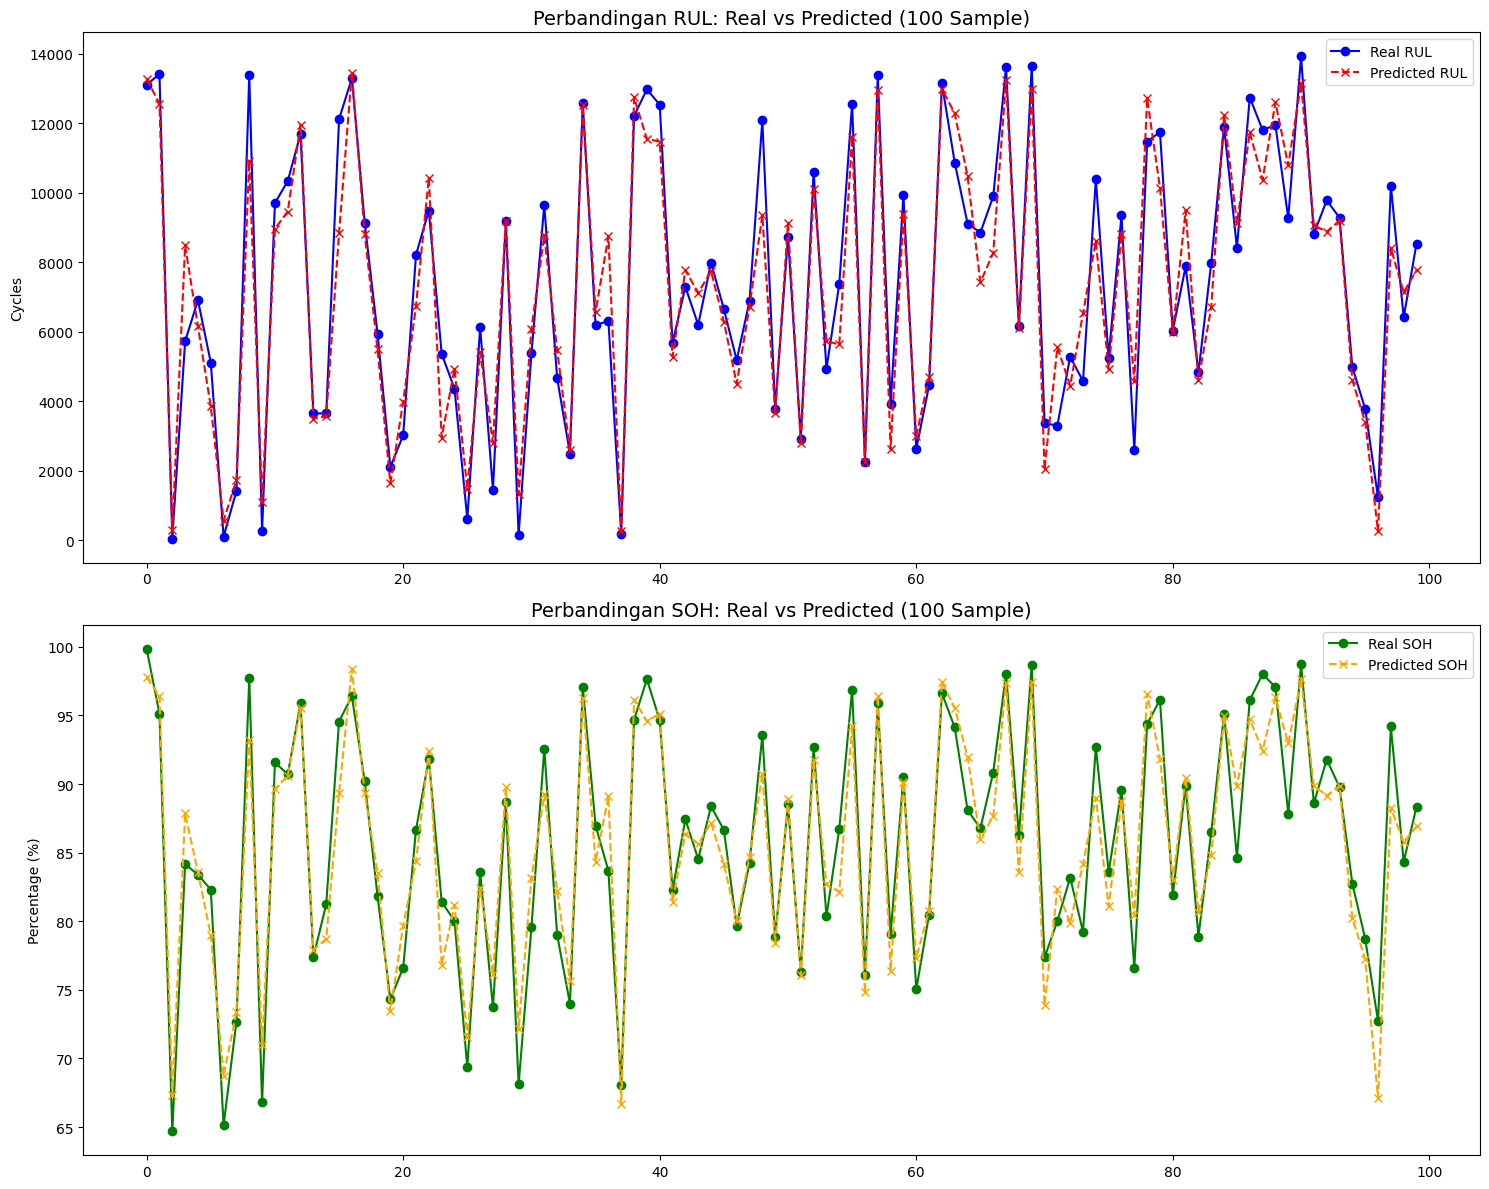

In [10]:
# Visualisasi Hasil Real vs Predicted (Line Chart)
# Kita ambil sampel 100 data agar grafik tidak terlalu padat
sample_indices = np.random.choice(len(y_test), 100, replace=False)
y_test_sample = y_test.iloc[sample_indices].reset_index(drop=True)
y_pred_sample = y_pred[sample_indices]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12))

# Plot RUL
ax1.plot(y_test_sample['rul'], label='Real RUL', marker='o', linestyle='-', color='blue')
ax1.plot(y_pred_sample[:, 0], label='Predicted RUL', marker='x', linestyle='--', color='red')
ax1.set_title('Perbandingan RUL: Real vs Predicted (100 Sample)', fontsize=14)
ax1.set_ylabel('Cycles')
ax1.legend()

# Plot SOH
ax2.plot(y_test_sample['soh'], label='Real SOH', marker='o', linestyle='-', color='green')
ax2.plot(y_pred_sample[:, 1], label='Predicted SOH', marker='x', linestyle='--', color='orange')
ax2.set_title('Perbandingan SOH: Real vs Predicted (100 Sample)', fontsize=14)
ax2.set_ylabel('Percentage (%)')
ax2.legend()

plt.tight_layout()
plt.show()

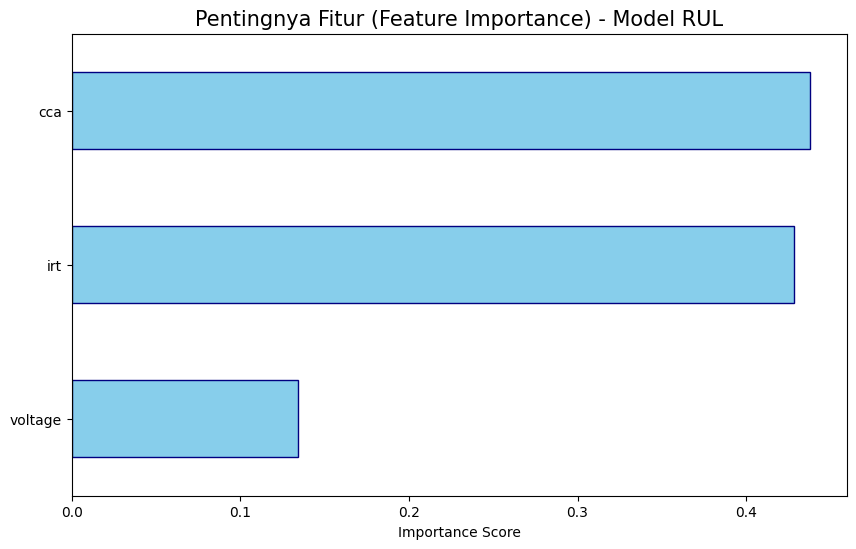

In [11]:
# Feature Importance Visualization
# Karena MultiOutputRegressor, kita ambil importance dari regressor pertama (RUL)
importances = pipeline.named_steps['regressor'].estimators_[0].feature_importances_
feat_importances = pd.Series(importances, index=features)

plt.figure(figsize=(10, 6))
feat_importances.sort_values().plot(kind='barh', color='skyblue', edgecolor='navy')
plt.title('Pentingnya Fitur (Feature Importance) - Model RUL', fontsize=15)
plt.xlabel('Importance Score')
plt.show()

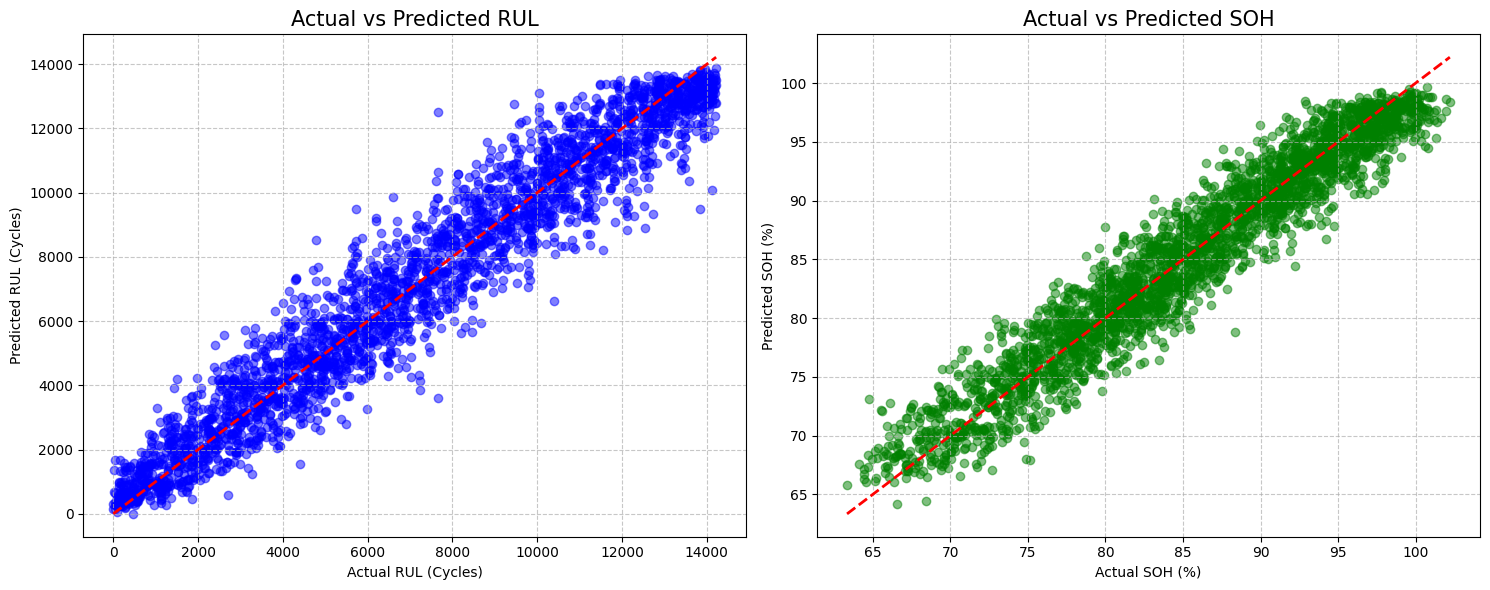

In [12]:
# 10. Analisis Error (Actual vs Predicted Plot)
# Menunjukkan perbandingan nilai aktual dan prediksi
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Actual vs Predicted RUL
axes[0].scatter(y_test['rul'], y_pred[:, 0], alpha=0.5, color='blue')
axes[0].plot([y_test['rul'].min(), y_test['rul'].max()], [y_test['rul'].min(), y_test['rul'].max()], 'r--', lw=2)
axes[0].set_title('Actual vs Predicted RUL', fontsize=15)
axes[0].set_xlabel('Actual RUL (Cycles)')
axes[0].set_ylabel('Predicted RUL (Cycles)')
axes[0].grid(True, linestyle='--', alpha=0.7)

# Actual vs Predicted SOH
axes[1].scatter(y_test['soh'], y_pred[:, 1], alpha=0.5, color='green')
axes[1].plot([y_test['soh'].min(), y_test['soh'].max()], [y_test['soh'].min(), y_test['soh'].max()], 'r--', lw=2)
axes[1].set_title('Actual vs Predicted SOH', fontsize=15)
axes[1].set_xlabel('Actual SOH (%)')
axes[1].set_ylabel('Predicted SOH (%)')
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


## 5. Feature Importance Analysis

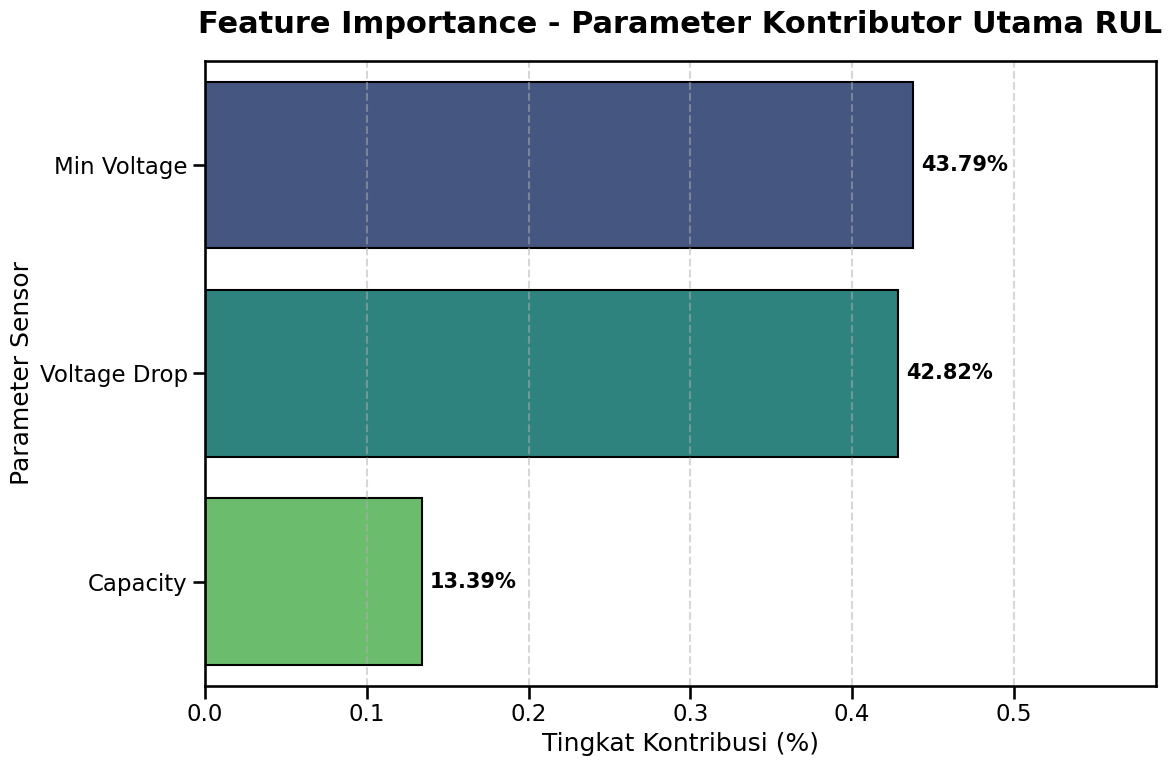

In [13]:
# 7. Analisis Parameter Paling Berpengaruh (Feature Importance)
# Menunjukkan kontribusi persentase dari setiap sensor terhadap prediksi RUL.
import pandas as pd
import seaborn as sns

# Ambil data Importance dari model XGBoost RUL di dalam pipeline
xgb_model_rul = pipeline.named_steps['regressor'].estimators_[0]
df_imp = pd.DataFrame({
    'Parameter Sensor': ['Capacity', 'Voltage Drop', 'Min Voltage'],
    'Skor Kepentingan': xgb_model_rul.feature_importances_
}).sort_values(by='Skor Kepentingan', ascending=False)

# Plotting dengan High Clarity & Fix FutureWarning
plt.figure(figsize=(12, 8))
sns.set_context("talk") 
ax = sns.barplot(
    x='Skor Kepentingan', 
    y='Parameter Sensor', 
    data=df_imp, 
    hue='Parameter Sensor', # Fix FutureWarning
    palette='viridis', 
    edgecolor='black',
    legend=False # Fix FutureWarning
)

# Tambahkan label persentase di ujung batang
for p in ax.patches:
    width = p.get_width()
    plt.text(width + 0.005, p.get_y() + p.get_height()/2, f'{width*100:.2f}%', va='center', fontweight='bold', fontsize=15)

plt.title('Feature Importance - Parameter Kontributor Utama RUL', pad=20, fontsize=22, fontweight='bold')
plt.xlabel('Tingkat Kontribusi (%)', fontsize=18)
plt.ylabel('Parameter Sensor', fontsize=18)
plt.xlim(0, df_imp['Skor Kepentingan'].max() + 0.15) # Beri ruang lebih untuk teks
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## 6. Outlier Detection

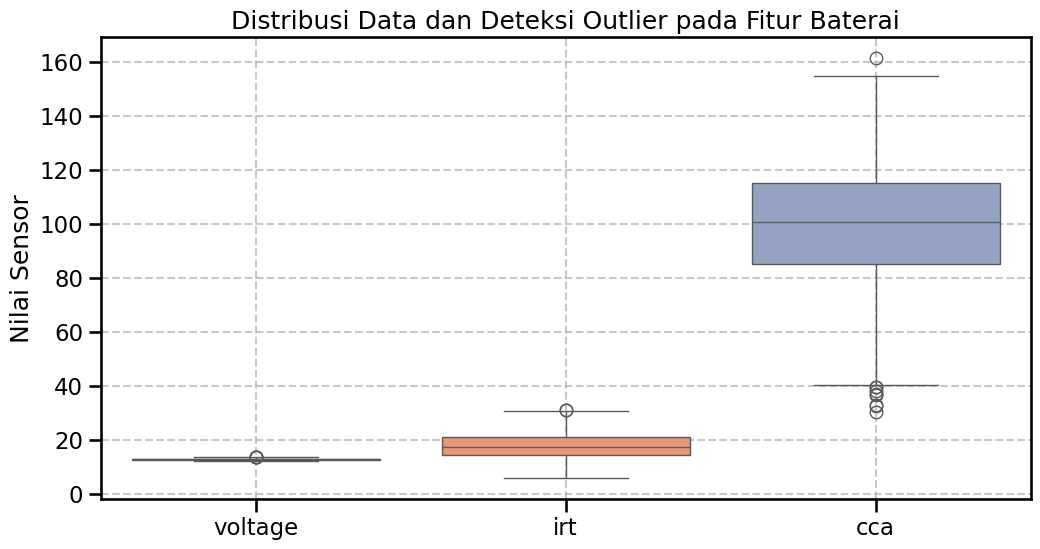

In [14]:
# 8. Deteksi Outlier pada Data Sensor
import seaborn as sns
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[features], palette='Set2')
plt.title('Distribusi Data dan Deteksi Outlier pada Fitur Baterai')
plt.ylabel('Nilai Sensor')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## 7. Export Production Model

In [15]:
# 6. Save Model
# Simpan pipeline dengan nama v2 agar sinkron dengan Backend
model_path = '../backend/model_battery_v2.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(pipeline, f)
    
print(f"Model successfully saved to {model_path}")


Model successfully saved to ../backend/model_battery_v2.pkl
